# **Numpy的索引切片**

In [4]:
import numpy as np

nd2 = np.random.randint(-5,15,size=(5,6))
nd2

array([[-3, -2, -3, 13, 14,  6],
       [13, 14, -3, 14,  8,  3],
       [10, -3, -4, 10,  3,  3],
       [-1, -4,  5,  6, 10,  3],
       [ 8,  3, -5,  9, 13, -2]], dtype=int32)

In [5]:
nd2[[1,3]] # 获取第二三行

array([[13, 14, -3, 14,  8,  3],
       [-1, -4,  5,  6, 10,  3]], dtype=int32)

In [6]:
nd2[:,[1,3,5]] # 获取第2、4、6列

array([[-2, 13,  6],
       [14, 14,  3],
       [-3, 10,  3],
       [-4,  6,  3],
       [ 3,  9, -2]], dtype=int32)

In [8]:
nd2[[1,3],[1,3,5]] # 会报错,因为1,1和3,3结合,没人和5结合

IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (2,) (3,) 

In [9]:
nd2[[1,3],[3,5]]

array([14,  3], dtype=int32)

### 方式一

In [10]:
#解决上面的方法是
nd2[[1,3]][:,[1,3,5]]

array([[14, 14,  3],
       [-4,  6,  3]], dtype=int32)

### 方式二

In [11]:
# np.ix_可以获取行和列
np.ix_([1,3],[1,3,5])

(array([[1],
        [3]]),
 array([[1, 3, 5]]))

In [14]:
# 新的索引
index = np.ix_([1,3],[1,3,5])

nd2[index] # = nd2[[1,3]][:,[1,3,5]]

array([[14, 14,  3],
       [-4,  6,  3]], dtype=int32)

# **Numpy形状改变**

In [15]:
import numpy as np

arr = np.arange(0,12)
arr

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [16]:
arr.shape = (3,4)
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [20]:
nd2 = np.random.randint(0,100,size=12)
display(nd2)

array([61, 42, 21, 40,  3, 88, 39, 79, 85, 64, 40, 94], dtype=int32)

In [21]:
nd2.shape = (3,4) # shape是定义形状
nd2

array([[61, 42, 21, 40],
       [ 3, 88, 39, 79],
       [85, 64, 40, 94]], dtype=int32)

In [26]:
display(nd2.reshape(4,3))  # reshape 可以改变形状,但是并没有改变原来的形状,算是一个新的数组

display(nd2.reshape(2,6))

array([[61, 42, 21],
       [40,  3, 88],
       [39, 79, 85],
       [64, 40, 94]], dtype=int32)

array([[61, 42, 21, 40,  3, 88],
       [39, 79, 85, 64, 40, 94]], dtype=int32)

In [30]:
display(nd2.reshape(-1,6)) # -1表示最后算,相当于x,6x = 12, x = 2 

display(nd2.reshape(-1)) # -1表示最后算,相当于x,x = 12, x = 12 

display(nd2.reshape(3,-1)) # 适合，不关心总数，灵活，预先算，自动算 

array([[61, 42, 21, 40,  3, 88],
       [39, 79, 85, 64, 40, 94]], dtype=int32)

array([61, 42, 21, 40,  3, 88, 39, 79, 85, 64, 40, 94], dtype=int32)

array([[61, 42, 21, 40],
       [ 3, 88, 39, 79],
       [85, 64, 40, 94]], dtype=int32)

In [31]:
nd2.reshape(3,5) # 会报错，因为3*5 = 15

ValueError: cannot reshape array of size 12 into shape (3,5)

## **数组的叠加**

In [32]:
import numpy as np

arr1 = np.random.randint(0,10,size=(2,4))

arr2 = np.random.randint(-5,5,(3,4))

display(arr1,arr2)

array([[1, 7, 4, 0],
       [4, 2, 4, 9]], dtype=int32)

array([[ 4, -4,  2, -4],
       [-1, -3, -2,  1],
       [-2,  1, -5, -1]], dtype=int32)

In [35]:
# concatenate的中文意思是：聚合，合并
np.concatenate([arr1,arr2]) # 变成了五行四列,默认行合并

array([[ 1,  7,  4,  0],
       [ 4,  2,  4,  9],
       [ 4, -4,  2, -4],
       [-1, -3, -2,  1],
       [-2,  1, -5, -1]], dtype=int32)

In [36]:
np.concatenate([arr1,arr2,arr1]) #还可以继续叠加，重复叠加

array([[ 1,  7,  4,  0],
       [ 4,  2,  4,  9],
       [ 4, -4,  2, -4],
       [-1, -3, -2,  1],
       [-2,  1, -5, -1],
       [ 1,  7,  4,  0],
       [ 4,  2,  4,  9]], dtype=int32)

In [47]:
arr1 = np.random.randint(0,10,size=(3,5))

arr2 = np.random.randint(-5,5,(3,4))

display(arr1,arr2)

array([[0, 9, 6, 8, 8],
       [6, 1, 2, 8, 4],
       [0, 0, 7, 5, 9]], dtype=int32)

array([[ 4, -1,  1, -1],
       [ 4,  1, -4, -3],
       [ 4, -3, -3, -1]], dtype=int32)

In [48]:
np.concatenate([arr1,arr2]) # 合并不了，因为形状不匹配，列得一样，或者利用参数 axis

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 5 and the array at index 1 has size 4

In [50]:
# display(np.concatenate([arr1,arr2],axis=1)) # axis = 1的时候等于列 列合并

display(np.concatenate([arr1,arr2],axis=-1)) # -1表示倒着数

array([[ 0,  9,  6,  8,  8,  4, -1,  1, -1],
       [ 6,  1,  2,  8,  4,  4,  1, -4, -3],
       [ 0,  0,  7,  5,  9,  4, -3, -3, -1]], dtype=int32)

## **拆分**

In [51]:
import numpy as np

nd = np.random.randint(0,100,(6,9))

display(nd)

array([[70, 78, 88, 45, 94, 16, 97, 11, 39],
       [63, 13, 22, 65, 32, 37, 83, 34, 66],
       [ 4, 39, 21, 63, 27, 56, 98, 48, 80],
       [30, 39, 31, 57, 32, 33, 97, 24, 59],
       [30, 45,  6, 37, 32, 94, 35, 82, 17],
       [31, 91, 12, 16, 44, 70, 33, 76, 89]], dtype=int32)

In [55]:
np.split(nd,2) # 第二个参数indices_or_sections是平均拆分
# 给一个数字就是代表平均分成多少份

[array([[70, 78, 88, 45, 94, 16, 97, 11, 39],
        [63, 13, 22, 65, 32, 37, 83, 34, 66],
        [ 4, 39, 21, 63, 27, 56, 98, 48, 80]], dtype=int32),
 array([[30, 39, 31, 57, 32, 33, 97, 24, 59],
        [30, 45,  6, 37, 32, 94, 35, 82, 17],
        [31, 91, 12, 16, 44, 70, 33, 76, 89]], dtype=int32)]

In [56]:
# 列表.表示.节点进行拆分
np.split(nd,[1,3,5],axis = 0)

[array([[70, 78, 88, 45, 94, 16, 97, 11, 39]], dtype=int32),
 array([[63, 13, 22, 65, 32, 37, 83, 34, 66],
        [ 4, 39, 21, 63, 27, 56, 98, 48, 80]], dtype=int32),
 array([[30, 39, 31, 57, 32, 33, 97, 24, 59],
        [30, 45,  6, 37, 32, 94, 35, 82, 17]], dtype=int32),
 array([[31, 91, 12, 16, 44, 70, 33, 76, 89]], dtype=int32)]

In [57]:
 np.split(nd,[1,3,5],axis = 1) # 列的拆分

[array([[70],
        [63],
        [ 4],
        [30],
        [30],
        [31]], dtype=int32),
 array([[78, 88],
        [13, 22],
        [39, 21],
        [39, 31],
        [45,  6],
        [91, 12]], dtype=int32),
 array([[45, 94],
        [65, 32],
        [63, 27],
        [57, 32],
        [37, 32],
        [16, 44]], dtype=int32),
 array([[16, 97, 11, 39],
        [37, 83, 34, 66],
        [56, 98, 48, 80],
        [33, 97, 24, 59],
        [94, 35, 82, 17],
        [70, 33, 76, 89]], dtype=int32)]

In [58]:
 np.split(nd,[1,3,5],axis = -1) # 列的拆分

[array([[70],
        [63],
        [ 4],
        [30],
        [30],
        [31]], dtype=int32),
 array([[78, 88],
        [13, 22],
        [39, 21],
        [39, 31],
        [45,  6],
        [91, 12]], dtype=int32),
 array([[45, 94],
        [65, 32],
        [63, 27],
        [57, 32],
        [37, 32],
        [16, 44]], dtype=int32),
 array([[16, 97, 11, 39],
        [37, 83, 34, 66],
        [56, 98, 48, 80],
        [33, 97, 24, 59],
        [94, 35, 82, 17],
        [70, 33, 76, 89]], dtype=int32)]

## **数组转置**

In [63]:
import numpy as np

A = np.random.randint(0,10,(3,5))
display(A)

display(A.reshape(5,3))

array([[2, 5, 6, 5, 4],
       [5, 2, 7, 1, 4],
       [5, 7, 3, 8, 3]], dtype=int32)

array([[2, 5, 6],
       [5, 4, 5],
       [2, 7, 1],
       [4, 5, 7],
       [3, 8, 3]], dtype=int32)

In [65]:
display(A.T) # 行列反转 T是transpose的缩写

array([[2, 5, 5],
       [5, 2, 7],
       [6, 7, 3],
       [5, 1, 8],
       [4, 4, 3]], dtype=int32)

In [68]:
display(np.transpose(A,axes = [1,0])) # axes表示行列颠倒，1代表列

array([[2, 5, 5],
       [5, 2, 7],
       [6, 7, 3],
       [5, 1, 8],
       [4, 4, 3]], dtype=int32)

# **Numpy广播机制**
## **当两个数组形状不相同的时候，可以用广播扩展数组实现叠加，相加相减相乘等操作**

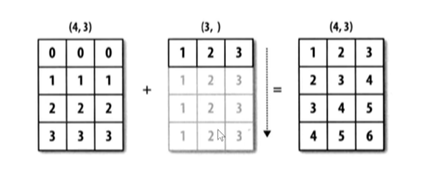

In [72]:
import numpy as np

arr1 = np.sort(np.array([0,1,2,3]*3))
arr1.shape = (4,3)
arr1

array([[0, 0, 0],
       [1, 1, 1],
       [2, 2, 2],
       [3, 3, 3]])

In [73]:
arr2 = np.arange(1,4)
arr2

array([1, 2, 3])

In [81]:
arr1 + arr2 # 广播机制，每个都加了1，2，3

array([[1, 2, 3],
       [2, 3, 4],
       [3, 4, 5],
       [4, 5, 6]])

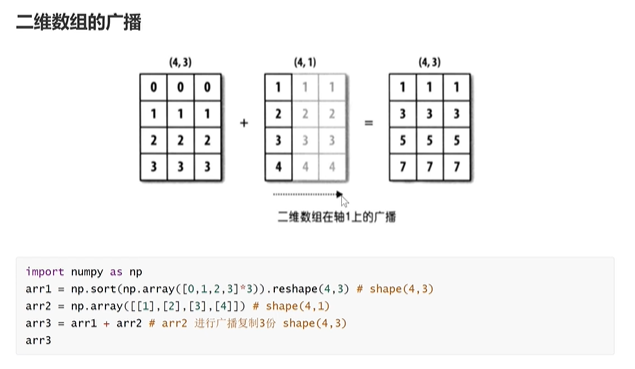

In [83]:
arr3 = np.random.randint(0,10,(4,5))
arr3

array([[7, 8, 9, 0, 1],
       [2, 0, 7, 3, 8],
       [4, 8, 4, 0, 9],
       [6, 9, 0, 5, 6]], dtype=int32)

In [93]:
arr4 = arr3.mean(axis = 1) # mean 每一行的平均值
arr4

array([5. , 4. , 5. , 5.2])

In [95]:
display(arr4.reshape(-1,1))

array([[5. ],
       [4. ],
       [5. ],
       [5.2]])

In [98]:
arr3 - arr4 # 列数不匹配，这是一位数组的广播 arr4只有4列,arr3有五列,所以广播不了，只能转换成4行广播

ValueError: operands could not be broadcast together with shapes (4,5) (4,) 

In [96]:
arr3 - arr4.reshape(-1,1)

array([[ 2. ,  3. ,  4. , -5. , -4. ],
       [-2. , -4. ,  3. , -1. ,  4. ],
       [-1. ,  3. , -1. , -5. ,  4. ],
       [ 0.8,  3.8, -5.2, -0.2,  0.8]])

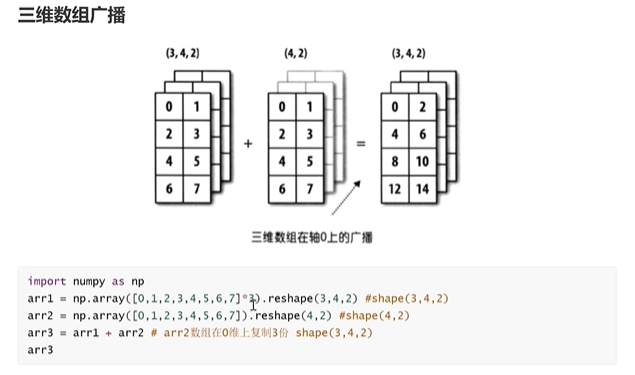

In [101]:
arr5 = np.random.randint(0,10,(3,4,2))
arr6 = np.arange(1,5)
arr6.shape = (4,-1)

display(arr5)

display(arr6)

array([[[7, 7],
        [7, 9],
        [8, 0],
        [3, 7]],

       [[9, 8],
        [9, 5],
        [7, 9],
        [8, 0]],

       [[0, 6],
        [5, 2],
        [2, 9],
        [8, 6]]], dtype=int32)

array([[1],
       [2],
       [3],
       [4]])

In [102]:
arr5 + arr6

array([[[ 8,  8],
        [ 9, 11],
        [11,  3],
        [ 7, 11]],

       [[10,  9],
        [11,  7],
        [10, 12],
        [12,  4]],

       [[ 1,  7],
        [ 7,  4],
        [ 5, 12],
        [12, 10]]])

# **Numpy通用函数**

### 一般函数 

In [1]:
import numpy as np

# sin表示三角函数的sin
# pi等于半圆
# pi / 2 等于 90度
display(np.sin(np.pi/2))

# 计算机有精确度的问题，e的-17次幂, 只需要.round(保存的小数)
display(np.cos(np.pi /2))

display(np.cos(np.pi / 2).round(1))

np.float64(1.0)

np.float64(6.123233995736766e-17)

np.float64(0.0)

In [2]:
# 开平方
display(np.sqrt(1024))

np.float64(32.0)

In [3]:
# 平方
display(np.square(8))

np.int64(64)

In [4]:
# 选择平几次方pow(需要平方的参数,平方的次数)
display(np.pow(3,3))

display(np.power(27,1/3))

np.int32(27)

np.float64(3.0)

In [5]:
# 三次方的函数定义
def fun(x):
    return x**3

fun(3)

27

In [6]:
# 开三次方的函数定义
def fun2(x):
    return x**(1/3)

fun2(27)

3.0

In [25]:
arr =np.set_printoptions(suppress=True)
arr = np.logspace(0,11,base=3,num=12,dtype='int')
display(arr)

display(fun2(arr).astype(int))

array([     1,      3,      9,     27,     81,    243,    729,   2187,
         6561,  19683,  59049, 177147])

array([ 1,  1,  2,  3,  4,  6,  8, 12, 18, 26, 38, 56])

In [8]:
# 开方
np.log2(16)

np.float64(4.0)

In [9]:
# 返回两个数组中每个元素的较大数值
x = np.array([1,5,2,9,3,6,8])
y = np.array([2,4,3,7,1,9,0])
np.maximum(x,y)

array([2, 5, 3, 9, 3, 9, 8])

In [10]:
arr2 = np.random.randint(0,10,(5,5))
display(arr2)

array([[5, 5, 0, 3, 8],
       [4, 8, 5, 8, 3],
       [8, 9, 2, 1, 5],
       [5, 6, 4, 9, 9],
       [3, 9, 4, 5, 7]], dtype=int32)

In [12]:
np.inner(arr2[0],arr2) # 返回一堆数组的向量内积

array([123, 108, 128, 154, 131], dtype=int32)

In [13]:
arr3 = np.random.randint(0,10,(2,2))
display(arr3)

array([[7, 4],
       [4, 5]], dtype=int32)

In [15]:
display(arr3[0])

array([7, 4], dtype=int32)

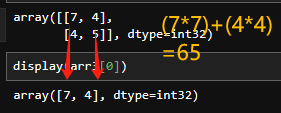

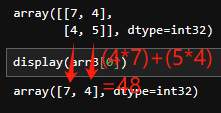

In [16]:
np.inner(arr3[0],arr3)

array([65, 48], dtype=int32)

In [29]:
a = 3.99999
display(np.ceil(a)) # 向上取整

display(np.floor(a)) # 向下取整

np.float64(4.0)

np.float64(3.0)

In [31]:
arr = np.arange(1,5)
np.exp(arr) # 指数运算 e^1 e^2 e^3 e^4

array([ 2.71828183,  7.3890561 , 20.08553692, 54.59815003])

In [34]:
np.abs(arr) # 绝对值

array([1, 2, 3, 4])

In [36]:
np.all(arr) # 判断元素是否有0

np.True_

In [38]:
np.any(arr) # 判断是否有元素

np.True_

In [48]:
arr = np.random.randint(0,30,(20))
display(np.clip(arr,10,20)) #将数组中的元素限制在指定的范围内
# 取的数值是大于第一个参数,小于第二个参数

array([20, 20, 10, 10, 20, 20, 10, 20, 17, 11, 10, 10, 10, 16, 20, 20, 20,
       10, 20, 10], dtype=int32)

In [43]:
# 用于二维数组及以上,一位数组用不了,用于计算矩阵的迹（即对角线元素的和）,返回标量值
arr.shape = (2,2)
display(arr)
np.trace(arr)

array([[1, 2],
       [3, 4]])

np.int64(5)

### Where函数 

In [50]:
import numpy as np

arr1 = np.array([1,3,5,7,9])
arr2 = np.array([2,4,6,8,10])

cond = np.array([True,False,True,True,False])

np.where(cond,arr1,arr2) # True返回arr1的值,False返回arr2的值
# where就是根据条件找数据

array([ 1,  4,  5,  7, 10])

In [51]:
np.maximum(arr1,arr2) # 每一列的最大值

array([ 2,  4,  6,  8, 10])

In [54]:
arr2 = np.random.randint(0,30,(20))

display(arr2)

np.where(arr2 < 15,arr2,1024) # True返回arr2, False返回1024

array([23,  1, 20,  4, 28,  7, 15, 16, 13, 11, 21, 16, 25,  9, 14, 23, 20,
       22, 15, 18], dtype=int32)

array([1024,    1, 1024,    4, 1024,    7, 1024, 1024,   13,   11, 1024,
       1024, 1024,    9,   14, 1024, 1024, 1024, 1024, 1024], dtype=int32)

In [56]:
arr3 = np.random.randint(-10,180,(50))
arr3

array([122, 118,  79,  54,  34, 100,  -9, 170,  38, 118,  37, 110,  17,
       135,  62,  60,   4,   7,  29, 143, 160, 126, 127,  -6,  68, 111,
        90,  14, 160, 148,  47,  54,  61,  -4, 133, 130,  -3,  40,  13,
       144,   9,  53,  69, 160,  -3, 105,  99, 108, 112, 108], dtype=int32)

In [64]:
np.where((arr3 < 0) | (arr3 > 150),'判错了',arr3)

array(['122', '118', '79', '54', '34', '100', '判错了', '判错了', '38', '118',
       '37', '110', '17', '135', '62', '60', '4', '7', '29', '143', '判错了',
       '126', '127', '判错了', '68', '111', '90', '14', '判错了', '148', '47',
       '54', '61', '判错了', '133', '130', '判错了', '40', '13', '144', '9',
       '53', '69', '判错了', '判错了', '105', '99', '108', '112', '108'],
      dtype='<U11')

### 集合运算函数

In [67]:
import numpy as np

A = np.random.randint(1,100,(20),dtype='int')
B = np.random.randint(1,100,(20),dtype='int')

display(A,B)

# 交集运算
display(np.intersect1d(A,B))

#并集运算
display(np.union1d(A,B))

#差集运算 A中有的，B中没有的
display(np.setdiff1d(A,B))

array([19, 75, 85, 35, 81, 38, 17, 12, 89,  8, 23, 85, 24, 39, 98, 46, 85,
       31, 48,  8])

array([ 2, 64, 60, 91, 82, 77, 77, 34,  1, 29, 99,  7, 33, 52, 92, 46, 68,
       87, 14, 93])

array([46])

array([ 1,  2,  7,  8, 12, 14, 17, 19, 23, 24, 29, 31, 33, 34, 35, 38, 39,
       46, 48, 52, 60, 64, 68, 75, 77, 81, 82, 85, 87, 89, 91, 92, 93, 98,
       99])

array([ 8, 12, 17, 19, 23, 24, 31, 35, 38, 39, 48, 75, 81, 85, 89, 98])

### 数学和统计函数 

In [76]:
import numpy as np

arr1 = np.array([1,2,3,4,5,6,7,8])
print('min : ',arr1.min())
print('max : ',arr1.max())
print('max of index : ',arr1.argmax())
print('min of index : ',arr1.argmin())
print('return > 5 element index : ',np.argwhere(arr1 > 5))
print('累加 : ',np.cumsum(arr1))

min :  1
max :  8
max of index :  7
min of index :  0
return > 5 element index :  [[5]
 [6]
 [7]]
累加 :  [ 1  3  6 10 15 21 28 36]
arr2 :  [[9 7 8 1 6]
 [8 3 0 2 7]
 [0 0 4 2 4]
 [3 4 2 6 0]]


In [77]:
arr2 = np.random.randint(0,10,size=(4,5))
print('arr2 : ',arr2)

arr2 :  [[0 2 7 1 9]
 [1 6 5 8 8]
 [8 4 4 3 3]
 [4 2 6 4 9]]


In [78]:
print('the col average is : ',arr2.mean(axis = 0))
print('the row average is : ',arr2.mean(axis = 1))

the col average is :  [3.25 3.5  5.5  4.   7.25]
the row average is :  [3.8 5.6 4.4 5. ]


In [79]:
print('协方差矩阵',np.cov(arr2,rowvar=True)) # 协方差矩阵
# 方差是自己和自己计算，协方差是自己和其他关联结算
# 方差是数据内部的波动，表示稳定性

协方差矩阵 [[15.7   5.15 -4.4   9.  ]
 [ 5.15  8.3  -5.8   2.5 ]
 [-4.4  -5.8   4.3  -1.75]
 [ 9.    2.5  -1.75  7.  ]]


In [80]:
print('相关系系数 : ',np.corrcoef(arr2,rowvar=True))

相关系系数 :  [[ 1.          0.45114729 -0.53551128  0.85850665]
 [ 0.45114729  1.         -0.97085578  0.32798346]
 [-0.53551128 -0.97085578  1.         -0.31897364]
 [ 0.85850665  0.32798346 -0.31897364  1.        ]]


### 线性代数

#### **矩阵的乘积**

In [87]:
import numpy as np

# 矩阵的乘积
A = np.array([4,2,3,1,3,1])
A.shape = (2,3)

B = np.array([2,7,-5,-7,9,3])
B.shape = (3,2)

display(A,B)

array([[4, 2, 3],
       [1, 3, 1]])

array([[ 2,  7],
       [-5, -7],
       [ 9,  3]])

In [90]:
# 矩阵乘法是点乘法
np.dot(A,B) # 矩阵运算 A的最后一堆和B的第一堆必须一致

array([[ 25,  23],
       [ -4, -11]])

In [92]:
A.dot(B)

array([[ 25,  23],
       [ -4, -11]])

In [91]:
A @ B # 符号 @ 表示矩阵的乘积运算

array([[ 25,  23],
       [ -4, -11]])

#### **矩阵其他运算**

In [1]:
import numpy as np
from numpy.linalg import inv,det,eig,qr,svd
A = np.array([1,2,3,2,3,4,4,5,8])
A.shape = (3,3)
A 

array([[1, 2, 3],
       [2, 3, 4],
       [4, 5, 8]])

In [9]:
np.set_printoptions(suppress=True)
B = inv(A) # 逆矩阵
display(B)

array([[-2. ,  0.5,  0.5],
       [ 0. ,  2. , -1. ],
       [ 1. , -1.5,  0.5]])

In [10]:
A.dot(B) # 单位矩阵

array([[ 1.,  0., -0.],
       [ 0.,  1.,  0.],
       [ 0., -0.,  1.]])

In [4]:
det(A) # 计算机矩阵行列式

np.float64(-2.0000000000000004)

In [5]:
eig(A) # 特征值

EigResult(eigenvalues=array([12.06912579, -0.44310504,  0.37397924]), eigenvectors=array([[ 0.30810498,  0.91959374, -0.02891232],
       [ 0.43997714, -0.08984659, -0.8289074 ],
       [ 0.84349952, -0.38245906,  0.55863817]]))

In [6]:
qr(A) # qr分解值

QRResult(Q=array([[-0.21821789, -0.81649658, -0.53452248],
       [-0.43643578, -0.40824829,  0.80178373],
       [-0.87287156,  0.40824829, -0.26726124]]), R=array([[-4.58257569, -6.11010093, -9.38336928],
       [ 0.        , -0.81649658, -0.81649658],
       [ 0.        ,  0.        , -0.53452248]]))

In [7]:
svd(A) #svd分解值

SVDResult(U=array([[-0.30590267,  0.80403283,  0.5098576 ],
       [-0.44236633,  0.35417612, -0.82393647],
       [-0.84305136, -0.4775882 ,  0.24733363]]), S=array([12.15104911,  0.48819731,  0.3371482 ]), Vh=array([[-0.37551002, -0.50647159, -0.77619505],
       [-0.81517804,  0.57897293,  0.01658628],
       [-0.44099544, -0.63896548,  0.63027465]]))

# Numpy实战分析csv里头的数据 2023年全球繁荣指数

In [59]:
import numpy as np

# load只适用于加载npz，npy
# csv用loadtxt
# skiprows指定跳过的行数。这里设置为 0，表示不跳过任何行，从文件的第一行开始读取。
# usecols指定要读取的列。这里设置为 0，表示只读取第 1 列（索引从 0 开始）。
# data = np.loadtxt('./data-work.csv',delimiter=',',dtype='str',usecols=0)
data = np.genfromtxt('./data-work.csv', dtype='str', delimiter=',', skip_header=1)
print(data)

[['?Denmark' '84.55' '76.81']
 ['?Sweden' '83.67' '76.18']
 ['?Norway' '83.59' '77.25']
 ['?Finland' '83.47' '70.28']
 ['??Switzerland' '83.42' '79.71']
 ['?Netherlands' '82.32' '74.34']
 ['?Luxembourg' '81.83' '76.93']
 ['?Iceland' '81.02' '69.92']
 ['?Germany' '80.81' '73.96']
 ['?New Zealand' '80.47' '69.88']
 ['?Ireland' '80.31' '77.81']
 ['?United Kingdom' '79.95' '73.31']
 ['?Canada' '79.62' '65.34']
 ['?Austria' '79.38' '68.41']
 ['?Australia' '79.36' '68.89']
 ['?Japan' '78.22' '66.35']
 ['?Singapore' '78.21' '80.1']
 ['?Belgium' '77.84' '66.39']
 ['?United States' '77.44' '72.34']
 ['?Taiwan' '77.36' '73.86']
 ['?Estonia' '77.31' '73.32']
 ['?Denmark' '84.55' '76.81']
 ['?Sweden' '83.67' '76.18']
 ['?Norway' '83.59' '77.25']
 ['?Finland' '83.47' '70.28']
 ['??Switzerland' '83.42' '79.71']
 ['?Netherlands' '82.32' '74.34']
 ['?Luxembourg' '81.83' '76.93']
 ['?Iceland' '81.02' '69.92']
 ['?Germany' '80.81' '73.96']
 ['?New Zealand' '80.47' '69.88']
 ['?Ireland' '80.31' '77.81']


In [60]:
# 提取国家和平均分数列
countries = data[:, 0]
scores = data[:, 1].astype(float)
economical_quantity = data[:,2].astype(float)

display(countries)

display(scores)

display(economical_quantity)

array(['?Denmark', '?Sweden', '?Norway', '?Finland', '??Switzerland',
       '?Netherlands', '?Luxembourg', '?Iceland', '?Germany',
       '?New Zealand', '?Ireland', '?United Kingdom', '?Canada',
       '?Austria', '?Australia', '?Japan', '?Singapore', '?Belgium',
       '?United States', '?Taiwan', '?Estonia', '?Denmark', '?Sweden',
       '?Norway', '?Finland', '??Switzerland', '?Netherlands',
       '?Luxembourg', '?Iceland', '?Germany', '?New Zealand', '?Ireland',
       '?United Kingdom', '?Canada', '?Austria', '?Australia', '?Japan',
       '?Singapore', '?Belgium', '?United States', '?Taiwan', '?Estonia',
       '?Hong Kong', '?France', '?Spain', '?Czech Republic', '?Portugal',
       '?Slovenia', '?Malta', '?South Korea', '?Italy', '?Latvia',
       '?Lithuania', '?Israel', '?Cyprus', '?Slovakia', '?Chile',
       '?Poland', '?Uruguay', '?Costa Rica', '?Greece', '?Croatia',
       '?Hungary', '?Malaysia', '?United Arab Emirates', '?Romania',
       '?Qatar', '?Mauritius', '?Bu

array([84.55, 83.67, 83.59, 83.47, 83.42, 82.32, 81.83, 81.02, 80.81,
       80.47, 80.31, 79.95, 79.62, 79.38, 79.36, 78.22, 78.21, 77.84,
       77.44, 77.36, 77.31, 84.55, 83.67, 83.59, 83.47, 83.42, 82.32,
       81.83, 81.02, 80.81, 80.47, 80.31, 79.95, 79.62, 79.38, 79.36,
       78.22, 78.21, 77.84, 77.44, 77.36, 77.31, 76.9 , 76.73, 76.03,
       75.08, 74.64, 74.54, 74.36, 74.07, 73.03, 72.99, 72.54, 72.25,
       71.82, 71.15, 70.18, 70.15, 69.69, 69.59, 68.48, 68.24, 66.88,
       66.84, 66.69, 66.4 , 66.24, 65.65, 65.55, 65.01, 64.32, 63.65,
       62.75, 62.28, 62.15, 61.95, 61.91, 61.39, 61.38, 61.27, 60.93,
       60.92, 60.92, 60.88, 60.79, 60.69, 60.07, 59.85, 59.85, 59.53,
       59.44, 59.3 , 59.11, 58.86, 58.84, 58.67, 58.56, 58.5 , 58.4 ,
       58.35, 58.34, 58.01, 57.91, 57.83, 57.53, 57.42, 57.14, 57.09,
       57.07, 56.93, 56.38, 56.34, 56.26, 55.91, 55.75, 55.5 , 55.19,
       55.05, 54.66, 54.46, 53.8 , 53.73, 53.68, 53.66, 53.44, 53.25,
       53.13, 52.38,

array([76.81, 76.18, 77.25, 70.28, 79.71, 74.34, 76.93, 69.92, 73.96,
       69.88, 77.81, 73.31, 65.34, 68.41, 68.89, 66.35, 80.1 , 66.39,
       72.34, 73.86, 73.32, 76.81, 76.18, 77.25, 70.28, 79.71, 74.34,
       76.93, 69.92, 73.96, 69.88, 77.81, 73.31, 65.34, 68.41, 68.89,
       66.35, 80.1 , 66.39, 72.34, 73.86, 73.32, 78.19, 65.81, 57.91,
       72.12, 60.63, 64.87, 72.04, 74.59, 57.77, 65.11, 65.4 , 70.96,
       62.65, 63.32, 63.25, 63.63, 55.53, 55.84, 49.58, 60.36, 66.05,
       64.98, 66.79, 62.04, 73.55, 52.93, 62.46, 54.03, 60.09, 48.05,
       55.37, 51.19, 68.46, 52.73, 53.22, 48.02, 41.86, 55.34, 59.91,
       50.35, 57.09, 55.98, 63.07, 45.44, 50.58, 54.85, 54.33, 63.31,
       47.17, 60.17, 52.37, 60.33, 51.37, 52.71, 50.06, 62.86, 60.83,
       57.77, 41.07, 50.01, 44.69, 56.28, 57.79, 42.97, 41.7 , 50.57,
       50.62, 54.77, 39.77, 40.95, 54.66, 41.64, 49.  , 53.04, 46.89,
       44.71, 39.68, 43.34, 50.63, 51.69, 41.66, 48.4 , 40.2 , 45.44,
       38.92, 54.13,

In [47]:
# 将国家和分数组合成一个数组
country_score_pairs = np.column_stack((countries, scores))
country_score_pairs

array([['?Denmark', '84.55'],
       ['?Sweden', '83.67'],
       ['?Norway', '83.59'],
       ['?Finland', '83.47'],
       ['??Switzerland', '83.42'],
       ['?Netherlands', '82.32'],
       ['?Luxembourg', '81.83'],
       ['?Iceland', '81.02'],
       ['?Germany', '80.81'],
       ['?New Zealand', '80.47'],
       ['?Ireland', '80.31'],
       ['?United Kingdom', '79.95'],
       ['?Canada', '79.62'],
       ['?Austria', '79.38'],
       ['?Australia', '79.36'],
       ['?Japan', '78.22'],
       ['?Singapore', '78.21'],
       ['?Belgium', '77.84'],
       ['?United States', '77.44'],
       ['?Taiwan', '77.36'],
       ['?Estonia', '77.31'],
       ['?Denmark', '84.55'],
       ['?Sweden', '83.67'],
       ['?Norway', '83.59'],
       ['?Finland', '83.47'],
       ['??Switzerland', '83.42'],
       ['?Netherlands', '82.32'],
       ['?Luxembourg', '81.83'],
       ['?Iceland', '81.02'],
       ['?Germany', '80.81'],
       ['?New Zealand', '80.47'],
       ['?Ireland', '80.31'],

In [55]:
# argsort和sort的区别是，argsort返回的是索引，sort返回的是值
sort = np.argsort(country_score_pairs[:, 1].astype(float))

187
186
185
184
183
182
181
180
179
178
177
176
175
174
173
172
171
170
169
168
167
166
165
164
163
162
161
160
159
158
157
156
155
154
153
152
151
150
149
148
147
146
145
144
143
142
141
140
139
138
137
136
135
134
133
132
131
130
129
128
127
126
125
124
123
122
121
120
119
118
117
116
115
114
113
112
111
110
109
108
107
106
105
104
103
102
101
100
99
98
97
96
95
94
93
92
91
90
89
87
88
86
85
84
83
81
82
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46
45
44
43
42
20
41
40
19
18
39
38
17
16
37
15
36
35
14
13
34
33
12
11
32
10
31
30
9
8
29
7
28
27
6
5
26
25
4
3
24
23
2
1
22
21
0


In [56]:
# 按分数排序
# 将sort里的索引传递给country_score_pairs,拿值
sorted_country_score_pairs = country_score_pairs[sort]
sorted_country_score_pairs

array([['?South Sudan', '30.4'],
       ['?Yemen', '32.65'],
       ['?Central African Republic', '32.83'],
       ['?Afghanistan', '34.18'],
       ['?Somalia', '34.39'],
       ['?Chad', '34.69'],
       ['?Democratic Republic of Congo', '35.74'],
       ['?Eritrea', '36.02'],
       ['?Syria', '36.83'],
       ['?Sudan', '36.97'],
       ['?Burundi', '38.2'],
       ['?Haiti', '39.82'],
       ['?Angola', '40.55'],
       ['?Mauritania', '41.23'],
       ['?Ethiopia', '41.87'],
       ['?Niger', '42.26'],
       ['?Mali', '42.36'],
       ['?Mozambique', '42.7'],
       ['?Guinea-Bissau', '42.78'],
       ['?Congo', '42.82'],
       ['?Cameroon', '43.08'],
       ['?Libya', '43.46'],
       ['?Venezuela', '43.6'],
       ['?Sierra Leone', '43.62'],
       ['?Myanmar?', '43.66'],
       ['?Nigeria', '44.0'],
       ['?Guinea', '44.47'],
       ['?Iraq', '44.66'],
       ['?Zimbabwe', '44.67'],
       ['?Liberia', '44.79'],
       ['?Madagascar', '44.94'],
       ['?Pakistan', '45.1']

In [57]:
# 打印排序后的结果
for country, score in sorted_country_score_pairs:
    print(f"{country}: {score}")

?South Sudan: 30.4
?Yemen: 32.65
?Central African Republic: 32.83
?Afghanistan: 34.18
?Somalia: 34.39
?Chad: 34.69
?Democratic Republic of Congo: 35.74
?Eritrea: 36.02
?Syria: 36.83
?Sudan: 36.97
?Burundi: 38.2
?Haiti: 39.82
?Angola: 40.55
?Mauritania: 41.23
?Ethiopia: 41.87
?Niger: 42.26
?Mali: 42.36
?Mozambique: 42.7
?Guinea-Bissau: 42.78
?Congo: 42.82
?Cameroon: 43.08
?Libya: 43.46
?Venezuela: 43.6
?Sierra Leone: 43.62
?Myanmar?: 43.66
?Nigeria: 44.0
?Guinea: 44.47
?Iraq: 44.66
?Zimbabwe: 44.67
?Liberia: 44.79
?Madagascar: 44.94
?Pakistan: 45.1
?Burkina Faso: 45.12
?Swaziland: 45.36
?Togo: 45.52
?Lesotho: 45.62
?Equatorial Guinea: 46.59
?Papua New Guinea: 46.64
?Uganda: 46.83
?Comoros: 46.93
?Zambia: 47.14
?Iran: 47.71
?Malawi: 47.83
?Bangladesh: 47.87
?Benin: 48.22
?Djibouti: 48.47
?Egypt: 48.57
?C?te d'Ivoire: 48.59
?Gabon: 48.84
?Cambodia: 49.19
?Tanzania: 49.2
?Gambia: 50.1
?Laos: 50.18
?Nicaragua: 50.22
?Tajikistan: 51.2
?Lebanon: 51.38
?Rwanda: 51.56
???Nepal: 51.57
?Algeria: 

In [62]:
all_database = np.column_stack([countries,scores,economical_quantity])
all_database

array([['?Denmark', '84.55', '76.81'],
       ['?Sweden', '83.67', '76.18'],
       ['?Norway', '83.59', '77.25'],
       ['?Finland', '83.47', '70.28'],
       ['??Switzerland', '83.42', '79.71'],
       ['?Netherlands', '82.32', '74.34'],
       ['?Luxembourg', '81.83', '76.93'],
       ['?Iceland', '81.02', '69.92'],
       ['?Germany', '80.81', '73.96'],
       ['?New Zealand', '80.47', '69.88'],
       ['?Ireland', '80.31', '77.81'],
       ['?United Kingdom', '79.95', '73.31'],
       ['?Canada', '79.62', '65.34'],
       ['?Austria', '79.38', '68.41'],
       ['?Australia', '79.36', '68.89'],
       ['?Japan', '78.22', '66.35'],
       ['?Singapore', '78.21', '80.1'],
       ['?Belgium', '77.84', '66.39'],
       ['?United States', '77.44', '72.34'],
       ['?Taiwan', '77.36', '73.86'],
       ['?Estonia', '77.31', '73.32'],
       ['?Denmark', '84.55', '76.81'],
       ['?Sweden', '83.67', '76.18'],
       ['?Norway', '83.59', '77.25'],
       ['?Finland', '83.47', '70.28'],
 

In [76]:
unique_countries = np.unique(all_database[:, 0],return_index=True)
print(len(unique_countries))
print(unique_countries)  # 打印前5个唯一国家名

2
(array(['???Nepal', '??Switzerland', '?Afghanistan', '?Albania',
       '?Algeria', '?Angola', '?Argentina', '?Armenia', '?Australia',
       '?Austria', '?Azerbaijan', '?Bahrain', '?Bangladesh', '?Belarus',
       '?Belgium', '?Belize', '?Benin', '?Bolivia',
       '?Bosnia and Herzegovina', '?Botswana', '?Brazil', '?Bulgaria',
       '?Burkina Faso', '?Burundi', "?C?te d'Ivoire", '?Cabo Verde',
       '?Cambodia', '?Cameroon', '?Canada', '?Central African Republic',
       '?Chad', '?Chile', '?China', '?Colombia', '?Comoros', '?Congo',
       '?Costa Rica', '?Croatia', '?Cuba', '?Cyprus', '?Czech Republic',
       '?Democratic Republic of Congo', '?Denmark', '?Djibouti',
       '?Dominican Republic', '?Ecuador', '?Egypt', '?El Salvador',
       '?Equatorial Guinea', '?Eritrea', '?Estonia', '?Ethiopia',
       '?Finland', '?France', '?Gabon', '?Gambia', '?Georgia', '?Germany',
       '?Ghana', '?Greece', '?Guatemala', '?Guinea', '?Guinea-Bissau',
       '?Guyana', '?Haiti', '?Hondur

In [80]:
# 使用 np.unique 去重，并返回唯一的国家名和它们的索引
unique_country,indices = np.unique(all_database[:,0],return_index=True)
unique_country

array(['???Nepal', '??Switzerland', '?Afghanistan', '?Albania',
       '?Algeria', '?Angola', '?Argentina', '?Armenia', '?Australia',
       '?Austria', '?Azerbaijan', '?Bahrain', '?Bangladesh', '?Belarus',
       '?Belgium', '?Belize', '?Benin', '?Bolivia',
       '?Bosnia and Herzegovina', '?Botswana', '?Brazil', '?Bulgaria',
       '?Burkina Faso', '?Burundi', "?C?te d'Ivoire", '?Cabo Verde',
       '?Cambodia', '?Cameroon', '?Canada', '?Central African Republic',
       '?Chad', '?Chile', '?China', '?Colombia', '?Comoros', '?Congo',
       '?Costa Rica', '?Croatia', '?Cuba', '?Cyprus', '?Czech Republic',
       '?Democratic Republic of Congo', '?Denmark', '?Djibouti',
       '?Dominican Republic', '?Ecuador', '?Egypt', '?El Salvador',
       '?Equatorial Guinea', '?Eritrea', '?Estonia', '?Ethiopia',
       '?Finland', '?France', '?Gabon', '?Gambia', '?Georgia', '?Germany',
       '?Ghana', '?Greece', '?Guatemala', '?Guinea', '?Guinea-Bissau',
       '?Guyana', '?Haiti', '?Honduras'

In [81]:
duplicate_database = all_database[indices]
duplicate_database

array([['???Nepal', '51.57', '45.33'],
       ['??Switzerland', '83.42', '79.71'],
       ['?Afghanistan', '34.18', '33.75'],
       ['?Albania', '60.69', '45.44'],
       ['?Algeria', '52.13', '39.95'],
       ['?Angola', '40.55', '41.81'],
       ['?Argentina', '61.38', '41.86'],
       ['?Armenia', '60.92', '50.35'],
       ['?Australia', '79.36', '68.89'],
       ['?Austria', '79.38', '68.41'],
       ['?Azerbaijan', '56.26', '54.66'],
       ['?Bahrain', '60.92', '57.09'],
       ['?Bangladesh', '47.87', '45.09'],
       ['?Belarus', '58.4', '60.83'],
       ['?Belgium', '77.84', '66.39'],
       ['?Belize', '55.91', '41.64'],
       ['?Benin', '48.22', '43.38'],
       ['?Bolivia', '53.13', '38.92'],
       ['?Bosnia and Herzegovina', '59.11', '52.37'],
       ['?Botswana', '57.83', '56.28'],
       ['?Brazil', '60.07', '50.58'],
       ['?Bulgaria', '65.55', '62.46'],
       ['?Burkina Faso', '45.12', '41.36'],
       ['?Burundi', '38.2', '29.98'],
       ["?C?te d'Ivoire", '48.

In [88]:
score_sum = all_database[:,1].astype('float')
print("全部国家的总分,",np.sum(score_sum))
economical_quantity_sum = all_database[:,2].astype('float')
print("全部国家的经济质量总分",np.sum(economical_quantity_sum))

全部国家的总分, 11385.54
全部国家的经济质量总分 10143.35


In [89]:
score_sum = all_database[:,1].astype('float')
print("全部国家的累加和,",np.cumsum(score_sum))
economical_quantity_sum = all_database[:,2].astype('float')
print("全部国家的经济质量累加和",np.cumsum(economical_quantity_sum))

全部国家的累加和, [   84.55   168.22   251.81   335.28   418.7    501.02   582.85   663.87
   744.68   825.15   905.46   985.41  1065.03  1144.41  1223.77  1301.99
  1380.2   1458.04  1535.48  1612.84  1690.15  1774.7   1858.37  1941.96
  2025.43  2108.85  2191.17  2273.    2354.02  2434.83  2515.3   2595.61
  2675.56  2755.18  2834.56  2913.92  2992.14  3070.35  3148.19  3225.63
  3302.99  3380.3   3457.2   3533.93  3609.96  3685.04  3759.68  3834.22
  3908.58  3982.65  4055.68  4128.67  4201.21  4273.46  4345.28  4416.43
  4486.61  4556.76  4626.45  4696.04  4764.52  4832.76  4899.64  4966.48
  5033.17  5099.57  5165.81  5231.46  5297.01  5362.02  5426.34  5489.99
  5552.74  5615.02  5677.17  5739.12  5801.03  5862.42  5923.8   5985.07
  6046.    6106.92  6167.84  6228.72  6289.51  6350.2   6410.27  6470.12
  6529.97  6589.5   6648.94  6708.24  6767.35  6826.21  6885.05  6943.72
  7002.28  7060.78  7119.18  7177.53  7235.87  7293.88  7351.79  7409.62
  7467.15  7524.57  7581.71  7638.8   769

In [90]:
score_sum = all_database[:,1].astype('float')
print("全部国家的均值,",np.mean(score_sum))
economical_quantity_sum = all_database[:,2].astype('float')
print("全部国家的经济质量均值",np.mean(economical_quantity_sum))

全部国家的均值, 60.56138297872341
全部国家的经济质量均值 53.95398936170213


In [91]:
score_sum = all_database[:,1].astype('float')
print("全部国家的标准差,",np.std(score_sum))
economical_quantity_sum = all_database[:,2].astype('float')
print("全部国家的经济质量标准差",np.std(economical_quantity_sum))

全部国家的标准差, 14.384490547118304
全部国家的经济质量标准差 14.37140521342285


In [92]:
score_sum = all_database[:,1].astype('float')
print("全部国家的方差,",np.var(score_sum))
economical_quantity_sum = all_database[:,2].astype('float')
print("全部国家的经济质量方差",np.var(economical_quantity_sum))

全部国家的方差, 206.91356830013584
全部国家的经济质量方差 206.53728780839748


In [93]:
score_sum = all_database[:,1].astype('float')
print("全部国家分数的最小值,",np.min(score_sum))
economical_quantity_sum = all_database[:,2].astype('float')
print("全部国家的经济质量的最小值",np.min(economical_quantity_sum))

全部国家分数的最小值, 30.4
全部国家的经济质量的最小值 24.46


In [94]:
score_sum = all_database[:,1].astype('float')
print("全部国家分数的最大值,",np.max(score_sum))
economical_quantity_sum = all_database[:,2].astype('float')
print("全部国家的经济质量的最大值",np.max(economical_quantity_sum))

全部国家分数的最大值, 84.55
全部国家的经济质量的最大值 80.1
